In [1]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
from matplotlib.colors import LinearSegmentedColormap, Normalize  
from matplotlib import rcParams  

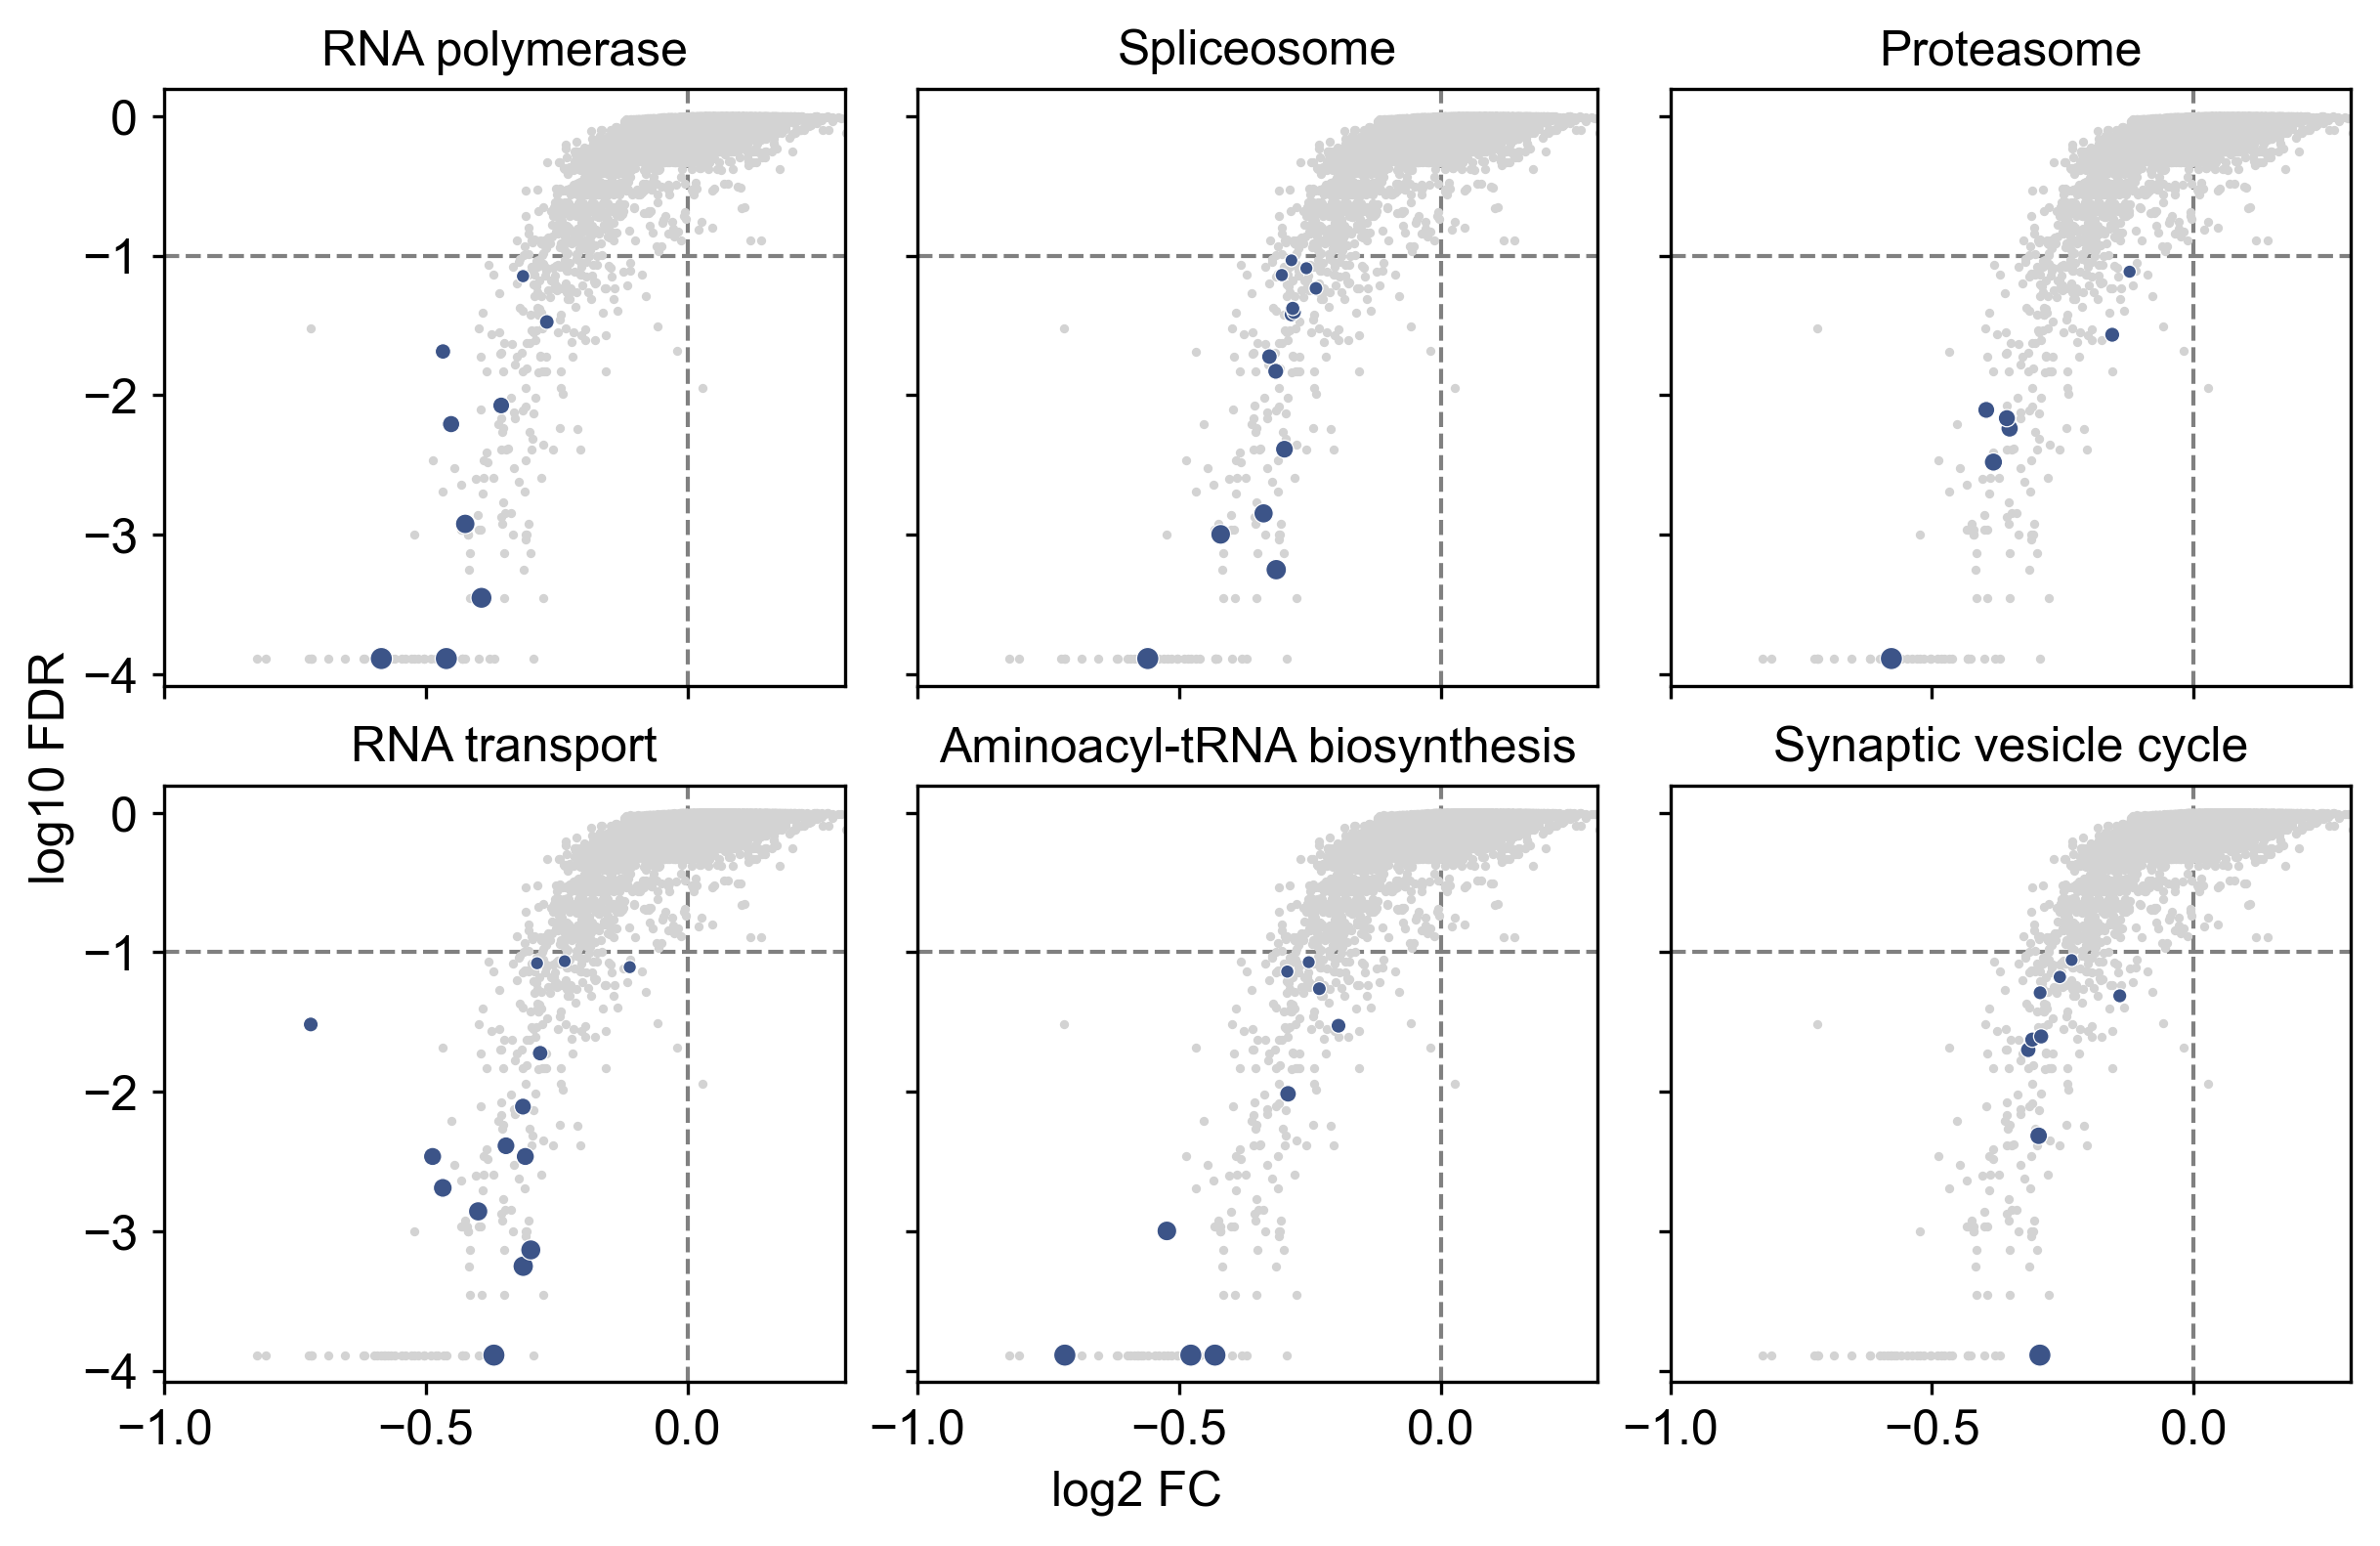

In [38]:


# ---- Load MAGeCK results ----
sample = 'Syn1-GW-4M'
gene_summary_path = '../new_mageck/Syn1-GW-all_4M/Syn1-GW-all_4M.gene_summary.txt'
df = pd.read_csv(gene_summary_path, sep='\t', comment='#')

# Use only negative side hits as before
df_hits = df[(df['hits'] == -1) & (df['neg|lfc'] < 0)]

# ---- Define your gene sets (example) ----
# Keys are panel names, values are lists of gene names as they appear in df['id'] or df['Gene']
# Make sure the column name used below matches your MAGeCK file (often 'id' or 'Gene')
gene_col = 'human homolog'   # change to the correct column name if different

# ---------- Gene sets ----------
gene_sets = {
    "RNA polymerase": [
        "POLR3A", "POLR2A", "POLR3B", "POLR1A", "POLR3C",
        "POLR3D", "POLR3E", "POLR2E", "POLR3K",
    ],
    "Spliceosome": [
        "ISY1", "HSPA8", "AQR", "SF3B2", "SF3A1", "DHX8", "RBM8A",
        "SF3B6", "PLRG1", "CRNKL1", "SART1", "SNW1", "DHX16", "RBM22",
    ],
    "Proteasome": [
        "PSMB6", "PSMB4", "PSMA4", "PSMA1",
        "PSMC3", "PSMC4", "PSMD2", "PSMC1",
    ],
    "RNA transport": [
        "NUP214", "EIF2B5", "PRMT5", "EIF2B3", "EIF2B2", "NUP210",
        "RBM8A", "TRNT1", "SENP2", "SNUPN", "GLE1", "NUP42",
        "GEMIN5", "NUP54",
    ],
    "Aminoacyl-tRNA biosynthesis": [
        "RARS2", "SARS1", "HARS1", "AARS2", "QARS1",
        "IARS2", "CARS1", "HARS2", "WARS1",
    ],
    "Synaptic vesicle cycle": [
        "NSF", "ATP6V0B", "STXBP1", "ATP6V1H", "ATP6V1E1",
        "ATP6V0D1", "ATP6V0E2", "ATP6V0C", "ATP6V1C1",
    ],
}

# ---------- Choose correct gene column ----------
gene_col = 'human homolog'  # change if needed, but don't overwrite later

# ---------- Cell-style rcParams with font size 10 ----------
cell_blue = "#3C5488FF"

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['font.size'] = 12              # global default font size
rcParams['axes.linewidth'] = 0.8
rcParams['xtick.major.width'] = 0.8
rcParams['ytick.major.width'] = 0.8
rcParams['xtick.major.size'] = 3
rcParams['ytick.major.size'] = 3
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['svg.fonttype'] = 'none'
rcParams['figure.dpi'] = 300

# ---------- Multi-panel volcano ----------
highlight_color = cell_blue

n_sets = len(gene_sets)
n_rows = 2
n_cols = int(np.ceil(n_sets / n_rows))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3 * n_cols, 3 * n_rows),
    dpi=300,
    sharex=True,
    sharey=True
)

axes = axes.ravel()

min_size, max_size = 10, 30
global_abs_fdr = -np.log10(df_hits['neg|fdr'])

for i, (ax, (set_name, genes)) in enumerate(zip(axes, gene_sets.items())):
    # Background: all genes in light grey
    ax.scatter(
        df['neg|lfc'],
        np.log10(df['neg|fdr']),
        s=3,
        c='lightgrey',
        alpha=1,
        edgecolors='lightgrey',
        linewidths=0.5,
        zorder=1
    )

    # Subset for this gene set
    set_df = df[df[gene_col].astype(str).isin(genes)].copy()
    set_hits = set_df[(set_df['hits'] == -1) & (set_df['neg|lfc'] < 0)].copy()

    if not set_hits.empty:
        # Point size mapping based on FDR
        set_sizes = np.interp(
            -np.log10(set_hits['neg|fdr']),
            (global_abs_fdr.min(), global_abs_fdr.max()),
            (min_size, max_size)
        )

        # Highlight genes in this set
        ax.scatter(
            set_hits['neg|lfc'],
            np.log10(set_hits['neg|fdr']),
            s=set_sizes,
            c=highlight_color,
            alpha=1,
            edgecolors='white',
            linewidths=0.3,
            zorder=2
        )

        # Top 5 by strongest depletion
        top5 = set_hits.nsmallest(5, 'neg|lfc')
        for _, row in top5.iterrows():
            x = row['neg|lfc']
            y = np.log10(row['neg|fdr'])
            gene_name = row[gene_col]
#             ax.text(
#                 x, y,
#                 gene_name,
#                 fontsize=12,   # label font size 10
#                 color='black',
#                 ha='right',
#                 va='bottom',
#                 clip_on=True,
#             )

        title = f"{set_name}"
    else:
        title = f"{set_name}"

    # Threshold/reference lines
    ax.axhline(np.log10(0.1), color='gray', linestyle='--', lw=1, zorder=0)
    ax.axvline(0, color='gray', linestyle='--', lw=1, zorder=0)
    ax.set_xlim(-1,0.3)
    # Panel title (size 10)
    ax.set_title(title, fontsize=12)

# Hide unused axes
for j in range(n_sets, len(axes)):
    axes[j].set_visible(False)

# Shared labels and figure title (size 10)
fig.text(0.5, 0.08, 'log2 FC', ha='center', fontsize=12)
fig.text(0.08, 0.5, 'log10 FDR', va='center', rotation='vertical', fontsize=12)
# fig.suptitle(sample, fontsize=12, y=0.98)

plt.tight_layout(rect=[0.08, 0.08, 0.98, 0.95], w_pad=0.5, h_pad=0.5)
plt.savefig('../enrichment/Syn1-GW-all_4M/pathway_gene_unlabeled.png',dpi=400)